# Thermal Simulator - First Order Model

Target:
- Simulate indoor temperature with a first-order thermal model
- Compare simulated vs measured data
- Validate if estimated k describes accurately enough the thermal system

### First-Order Equation
$T_{t+1} = T_t + (-k (T_t - T_{out})) \Delta T$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Import dataset from csv 
df_all = pd.read_csv('PreliminaryAnalysis.csv')
min_date = pd.to_datetime('2026-02-22 17:00:00')
df_all['time'] = pd.to_datetime(df_all['time'])
df = df_all.loc[df_all['time'] > min_date]
df = df.set_index("time")
df.head()

,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n
time,,,,,,,,
2026-02-22 18:00:00,19.33,20.04,63.81,56.66,9.23,70.83,11.63,63.32
2026-02-22 19:00:00,19.07,19.65,65.78,60.08,8.89,70.79,10.33,66.01
2026-02-22 20:00:00,19.44,19.84,66.32,61.13,8.64,71.44,9.66,68.00
2026-02-22 21:00:00,19.26,19.54,65.34,61.40,8.44,75.14,9.39,71.99
2026-02-22 22:00:00,19.01,19.30,66.37,61.25,8.35,75.18,9.20,72.20


In [3]:
# Parameters definition
column_in = "temp_salon_c"
column_out = "temp_out_1_b_c"
k = 0.011497 # as found in parameters_indentification
dt = 1.0 # hours

In [4]:
# Simulator function
def simulate_first_order(T0, Tout_series, k, dt=1.0):
    """
    T_{t+1} = T_t + (-k * (T_t - T_out)) * dt
    """
    Tsim = np.zeros(len(Tout_series), dtype=float)
    Tsim[0] = T0

    for i in range(1, len(Tout_series)):
        T_prev = Tsim[i-1]
        Tout = Tout_series.iloc[i-1]
        Tsim[i] = T_prev + (-k * (T_prev - Tout)) * dt

    return pd.Series(Tsim, index=Tout_series.index, name="Tsim")


In [5]:
# Initial Time window selection
df_sim = df.loc["2026-03-01":"2026-03-04", [column_in, column_out]].dropna().copy()
df_sim.head()


,temp_salon_c,temp_out_1_b_c
time,,
2026-03-01 00:00:00,18.05,7.50
2026-03-01 01:00:00,17.80,7.37
2026-03-01 02:00:00,17.60,7.26
2026-03-01 03:00:00,17.48,7.13
2026-03-01 04:00:00,17.30,7.03


##### Run Simulation
Initial condition -> first measured value

In [6]:
T0 = df_sim[column_in].iloc[0]
df_sim['Tsim'] = simulate_first_order(T0, df_sim[column_out], k)

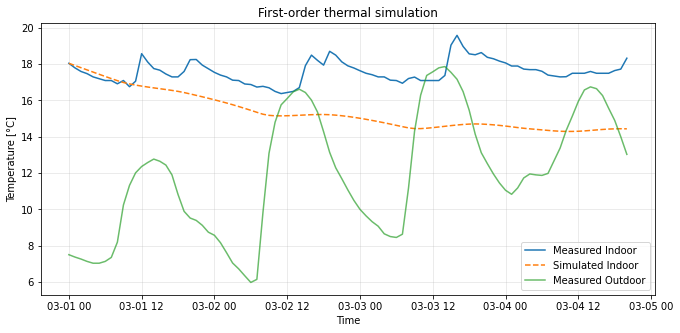

In [7]:
plt.figure(figsize=(11, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured Indoor")
plt.plot(df_sim.index, df_sim["Tsim"], label="Simulated Indoor", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Measured Outdoor", alpha=0.7)

plt.title("First-order thermal simulation")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Error metrics
mae = np.mean(np.abs(df_sim[column_in] - df_sim["Tsim"]))
rmse = np.sqrt(np.mean((df_sim[column_in] - df_sim["Tsim"])**2))

print(f"MAE  = {mae:.3f} °C")
print(f"RMSE  = {rmse:.3f} °C")


MAE  = 2.247 °C
RMSE  = 2.547 °C


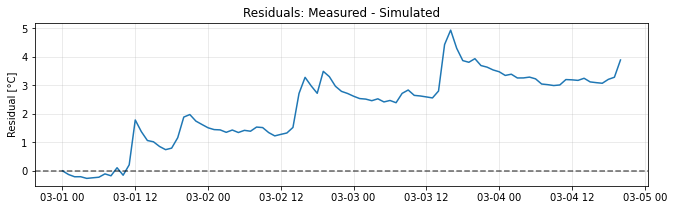

In [9]:
# Plot residuals
df_sim["residual"] = df_sim[column_in] - df_sim["Tsim"]

plt.figure(figsize=(11, 3))
plt.plot(df_sim.index, df_sim["residual"])
plt.axhline(0, color="k", linestyle="--", alpha=0.6)
plt.title("Residuals: Measured - Simulated")
plt.ylabel("Residual [°C]")
plt.grid(True, alpha=0.3)
plt.show()

# Results - 1

### First Order simulation plot

Outdoor temperature (green line) rise during day.
Measured indoor temperature (blue line) rise much higher than Tout can explain.

This probably means: ** solar gain **

This is confirmed also by the residuals plot. 
 * During nightime residuals are around 0.
 * During daytime residuals are systematically positive ($T_{measured} \gt T_{simulated}$).

## Prediction Model V2
Let's consider a model that takes solar gain into account. Something like:

$T_{t+1} =T_t + (−k(T_t − T_{out})+ g I_{day}(t)) \Delta t $
* I_{day}(t) = 1 if time in range 09:00–16:00
* 0 otherwise
* g in $^oC/h$

g can be estimated by trial-and-error at first.

In [21]:
# Simulator function V2
def simulate_first_order_with_solar(T0, Tout_series, k, dt=1.0, solar_gain=0.2, solar_start="10:00", solar_end="18:00"):
    """
    T_{t+1} = T_t + (-k * (T_t - T_out) + g * I_day) * dt
    """
    Tsim = np.zeros(len(Tout_series), dtype=float)
    Tsim[0] = T0

    # day indicator
    idx = Tout_series.index
    day_mask = ((idx.time >= pd.to_datetime(solar_start).time()) & (idx.time <= pd.to_datetime(solar_end).time())).astype(float)

    for i in range(1, len(Tout_series)):
        T_prev = Tsim[i-1]
        Tout = Tout_series.iloc[i-1]
        solar_term = solar_gain * day_mask[i-1]
        Tsim[i] = T_prev + (-k * (T_prev - Tout) + solar_term) * dt

    return pd.Series(Tsim, index=Tout_series.index, name="Tsim")

In [22]:
T0 = df_sim[column_in].iloc[0]

df_sim["Tsim_v1"] = simulate_first_order(T0, df_sim[column_out], k, dt=dt)
df_sim["Tsim_v2"] = simulate_first_order_with_solar(
    T0,
    df_sim[column_out],
    k=k,
    dt=dt,
    solar_gain=0.20,      
    solar_start="10:00",
    solar_end="18:00"
)


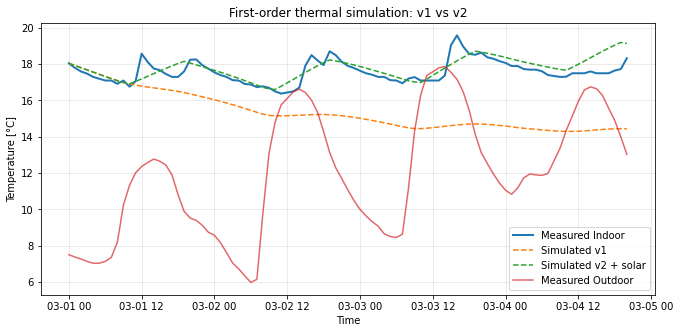

In [23]:
plt.figure(figsize=(11, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured Indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v1"], label="Simulated v1", linestyle="--")
plt.plot(df_sim.index, df_sim["Tsim_v2"], label="Simulated v2 + solar", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Measured Outdoor", alpha=0.7)
    
plt.title("First-order thermal simulation: v1 vs v2")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

mae_v1, rmse_v1 = compute_metrics(df_sim[column_in], df_sim["Tsim_v1"])
mae_v2, rmse_v2 = compute_metrics(df_sim[column_in], df_sim["Tsim_v2"])
print(f"V1 -> MAE: {mae_v1:.3f} °C | RMSE: {rmse_v1:.3f} °C")
print(f"V2 -> MAE: {mae_v2:.3f} °C | RMSE: {rmse_v2:.3f} °C")

V1 -> MAE: 2.247 °C | RMSE: 2.547 °C
V2 -> MAE: 0.373 °C | RMSE: 0.507 °C


In [25]:
for g in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    df_sim["Tsim_test"] = simulate_first_order_with_solar(
        T0,
        df_sim[column_out],
        k=k,
        dt=dt,
        solar_gain=g,
        solar_start="10:00",
        solar_end="18:00"
    )
    mae, rmse = compute_metrics(df_sim[column_in], df_sim["Tsim_test"])
    print(f"g={g:.2f} -> MAE={mae:.3f}, RMSE={rmse:.3f}")

g=0.05 -> MAE=1.651, RMSE=1.877
g=0.10 -> MAE=1.054, RMSE=1.224
g=0.15 -> MAE=0.501, RMSE=0.640
g=0.20 -> MAE=0.373, RMSE=0.507
g=0.25 -> MAE=0.837, RMSE=1.021
g=0.30 -> MAE=1.408, RMSE=1.662


### Model Validation
Try to apply V2 model in a different set of days

In [26]:
# Import dataset from csv 
df_vld = pd.read_csv('./Data/first_month_data.csv')
min_date = pd.to_datetime('2026-03-01 00:00:00')
max_date = pd.to_datetime('2026-03-10 23:00:00')
df_vld['time'] = pd.to_datetime(df_vld['time'])
df = df_vld.loc[(df_vld['time'] >= min_date) & (df_vld['time'] <= max_date)]
df = df.set_index("time")
df.head()

,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n
time,,,,,,,,
2026-03-01 00:00:00,18.05,18.81,64.7,62.4,7.50,62.03,7.99,60.46
2026-03-01 01:00:00,17.80,18.54,63.8,63.2,7.37,62.52,7.72,61.15
2026-03-01 02:00:00,17.60,18.35,63.7,63.4,7.26,62.93,7.60,62.20
2026-03-01 03:00:00,17.48,18.22,63.7,63.4,7.13,63.40,7.50,62.47
2026-03-01 04:00:00,17.30,18.10,63.7,63.4,7.03,62.89,7.41,61.49


In [27]:
df_sim_new = df.dropna().copy()
df_sim_new["Tsim_v2"] = simulate_first_order_with_solar(
    T0,
    df[column_out],
    k=k,
    dt=dt,
    solar_gain=0.20,      
    solar_start="10:00",
    solar_end="18:00"
)

mae_v2_new, rmse_v_new = compute_metrics(df_sim_new[column_in], df_sim_new["Tsim_v2"])
print(f"NEW MAE: {mae_v2_new:.3f} °C | RMSE: {rmse_v_new:.3f} °C")


NEW MAE: 0.770 °C | RMSE: 0.918 °C


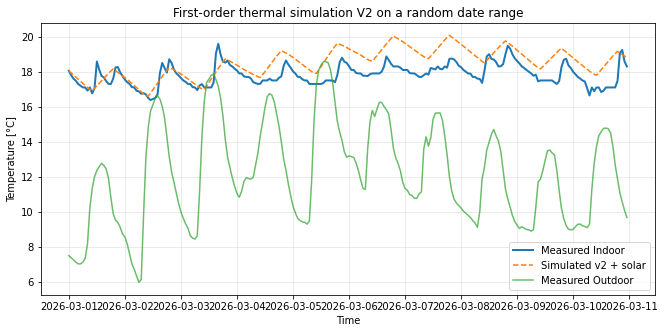

In [28]:
plt.figure(figsize=(11, 5))
plt.plot(df_sim_new.index, df_sim_new[column_in], label="Measured Indoor", linewidth=2)
plt.plot(df_sim_new.index, df_sim_new["Tsim_v2"], label="Simulated v2 + solar", linestyle="--")
plt.plot(df_sim_new.index, df_sim_new[column_out], label="Measured Outdoor", alpha=0.7)
    
plt.title("First-order thermal simulation V2 on a random date range")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Results - 2

Results have significantly improved. Simulator is able to perform much closer to the measured values. MAE and RMSE are low. 

Consquently, **k** parameter has a quite representative value.

One thing that could improved is the daytime jumps to be more "dynamical" instead of a constant value. So let's define g as:

$g(t) = \alpha max(T_{out, south}(t) - T_{out, north}(t), 0)$

and the equation of the model (V3) now becomes:

$T_{t+1} = T_t + [-k(T_t - T_{out, north}) + \alpha max(T_{out, south}(t) - T_{out, north}(t), 0)] \Delta t$

$\alpha$ means:
* gain scaling factor
* turns outdoor difference North-South to "effective heating input" for the northern room

In [29]:
def simulate_first_order_with_dynamic_solar(
    T0, 
    Tout_ref_series,
    Tout_north_series,
    Tout_south_series,
    k,
    alpha,
    dt=1.0
):
    """
    First-order thermal model with dynamic solar proxy:
    
    T_{t+1} = T_t + [-k*(T_t - T_out_ref) + alpha * max(T_out_south - T_out_north, 0)] * dt
    
    Parameters
    ----------
    T0 : float
        Initial indoor temperature
    Tout_ref_series : pd.Series
        Outdoor reference temperature for the room (e.g. north outdoor for north room)
    Tout_north_series : pd.Series
        North outdoor temperature
    Tout_south_series : pd.Series
        South outdoor temperature
    k : float
        Heat loss coefficient [1/h]
    alpha : float
        Dynamic solar gain scaling factor
    dt : float
        Time step in hours
    """
    idx =Tout_ref_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    Tsim[0] = T0

    solar_proxy = np.maximum((Tout_south_series - Tout_north_series).to_numpy(dtype=float), 0.0)

    for i in range(1, len(idx)):
        T_prev = Tsim[i - 1]
        T_out_ref = float(Tout_ref_series.iloc[i - 1])
        solar_term = alpha * solar_proxy[i - 1]

        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + solar_term) * dt
    return pd.Series(Tsim, index=idx, name="Tsim_v3")


In [30]:
column_in = "temp_salon_c"
column_out_north = "temp_out_1_b_c"
column_out_south = "temp_out_2_n_c"

In [31]:
df_sim = df.loc["2026-03-01":"2026-03-10", [
    column_in,
    column_out_north,
    column_out_south
]].dropna().copy()

T0 = df_sim[column_in].iloc[0]

In [35]:
df_sim["Tsim_v1"] = simulate_first_order(
    T0,
    df_sim[column_out_north],
    k,
    dt=dt
)

df_sim["Tsim_v3"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_ref_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k,
    alpha=0.05,   # αρχική δοκιμή
    dt=dt
)

In [36]:
for alpha in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]:
    df_sim["Tsim_test"] = simulate_first_order_with_dynamic_solar(
        T0=T0,
        Tout_ref_series=df_sim[column_out_north],
        Tout_north_series=df_sim[column_out_north],
        Tout_south_series=df_sim[column_out_south],
        k=k,
        alpha=alpha,
        dt=dt
    )
    
    mae, rmse = compute_metrics(df_sim[column_in], df_sim["Tsim_test"])
    print(f"alpha={alpha:.2f} -> MAE={mae:.3f}, RMSE={rmse:.3f}")

alpha=0.05 -> MAE=0.420, RMSE=0.539
alpha=0.10 -> MAE=3.873, RMSE=4.209
alpha=0.15 -> MAE=7.571, RMSE=8.188
alpha=0.20 -> MAE=11.272, RMSE=12.177
alpha=0.25 -> MAE=14.973, RMSE=16.169
alpha=0.30 -> MAE=18.675, RMSE=20.162
alpha=0.35 -> MAE=22.379, RMSE=24.155


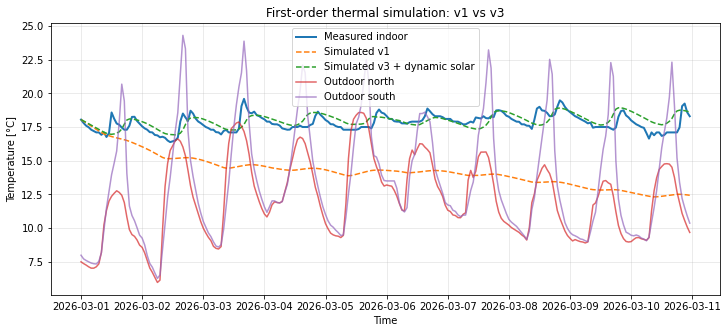

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v1"], label="Simulated v1", linestyle="--")
plt.plot(df_sim.index, df_sim["Tsim_v3"], label="Simulated v3 + dynamic solar", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out_north], label="Outdoor north", alpha=0.7)
plt.plot(df_sim.index, df_sim[column_out_south], label="Outdoor south", alpha=0.7)

plt.title("First-order thermal simulation: v1 vs v3")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

mae_v1, rmse_v1 = compute_metrics(df_sim[column_in], df_sim["Tsim_v1"])
mae_v3, rmse_v3 = compute_metrics(df_sim[column_in], df_sim["Tsim_v3"])

print(f"V1 -> MAE: {mae_v1:.3f} °C | RMSE: {rmse_v1:.3f} °C")
print(f"V3 -> MAE: {mae_v3:.3f} °C | RMSE: {rmse_v3:.3f} °C")

V1 -> MAE: 3.574 °C | RMSE: 3.844 °C
V3 -> MAE: 0.420 °C | RMSE: 0.539 °C


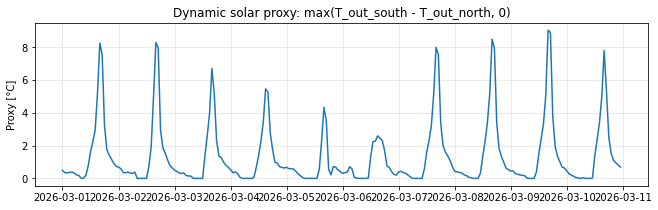

In [39]:
df_sim["solar_proxy"] = np.maximum(
    df_sim[column_out_south] - df_sim[column_out_north],
    0
)

plt.figure(figsize=(11, 3))
plt.plot(df_sim.index, df_sim["solar_proxy"])
plt.title("Dynamic solar proxy: max(T_out_south - T_out_north, 0)")
plt.ylabel("Proxy [°C]")
plt.grid(True, alpha=0.3)
plt.show()

# Results - 3

This simulator model (V3) works really well. But it has a significant drawback... It requires prior knowledge of outdoor temperatures.

Thus it can only be used as a grey box explanatory model, allowing to: 
* understand dynamics
* improve physical understanding
* identify the forcing term that misses

# Recap

### V1
$-k(T_{in} - T_{out})$

works well only at nightime
### V2
$-k(T_{in} - T_{out}) + gI_{day}$

good baselinen predictive model

### V3
$-k(T_{in} - T_{out}) + \alpha max(T_{out,south} - T_{out,north}, 0)$

works very well as explanatory/replay model